In [18]:
import boto3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io

In [5]:
# Load the files from the s3 bucket

s3_client = boto3.client('s3')

BUCKET_NAME = "dsan6000-tb1187"
FOLDER_NAME = "wikipedia-hourly"

# list object in bucket sub-folder
response = s3_client.list_objects_v2(Bucket = BUCKET_NAME, Prefix = FOLDER_NAME)

# List for dfs
dfs = []

# Loop to load the files
for obj in response['Contents']:
    key = obj['Key']

    # Grab object from s3
    s3_object = s3_client.get_object(Bucket=BUCKET_NAME, Key = key)
    file_content = s3_object['Body'].read()

    # Load object into dataframe
    df_hourly = pd.read_parquet(io.BytesIO(file_content))
    dfs.append(df_hourly)

# Combine dfs
df_combined = pd.concat(dfs, ignore_index = True)

In [6]:
df_combined.head()

,datetime,$schema,meta,id,type,namespace,title,title_url,comment,timestamp,...,wiki,parsedcomment,log_id,log_type,log_action,log_params,log_action_comment,patrolled,file_ts,file_ts_str
0,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Jake_O%...,2.063884e+09,edit,0,Jake O'Donnell,https://en.wikipedia.org/wiki/Jake_O%27Donnell,Fix dash,1788235202,...,enwiki,Fix dash,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
1,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Beverid...,2.063884e+09,edit,0,Beveridge Award,https://en.wikipedia.org/wiki/Beveridge_Award,Add source,1788235202,...,enwiki,Add source,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
2,2026-09-01 04:00:01,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1920_Un...,2.063884e+09,edit,0,1920 United States presidential election in Wa...,https://en.wikipedia.org/wiki/1920_United_Stat...,/* Counties that flipped from Democratic to Re...,1788235201,...,enwiki,"<span class=""autocomment""><a href=""/wiki/1920_...",NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
3,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1987_Ae...,2.063884e+09,edit,0,1987 Aegean crisis,https://en.wikipedia.org/wiki/1987_Aegean_crisis,added a bit of context,1788235202,...,enwiki,added a bit of context,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
4,2026-09-01 04:00:03,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Marvin_...,2.063884e+09,edit,0,Marvin Schwäbe,https://en.wikipedia.org/wiki/Marvin_Schw%C3%A4be,NaN,1788235203,...,enwiki,NaN,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000


In [12]:
# Convert to datetime type
df_combined['datetime'] = pd.to_datetime(df_combined['datetime'])

# extract hour from timestamp
df_combined['hour'] = df_combined['datetime'].dt.hour

# aggregate by total events/hour
df_total_hourly = df_combined.groupby('hour').size().reset_index(name="event_count")

# aggregate by events per hour
df_typed_hourly = df_combined.groupby(['hour', 'type']).size().reset_index(name='event_count')


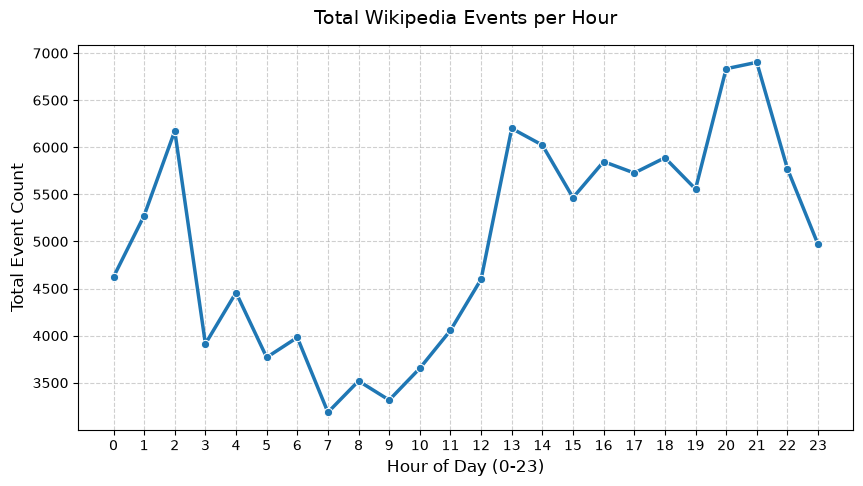

In [24]:
# Plot count of hourly events
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_total_hourly, x='hour', y='event_count', marker='o', linewidth=2.5)

plt.title("Total Wikipedia Events per Hour", fontsize=14, pad=15)
plt.xlabel("Hour of Day (0-23)", fontsize=12)
plt.ylabel("Total Event Count", fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)

# Save images (must come before plt.show(), which clears the figure)
plt.savefig("images/hourly-events.svg", format="svg", bbox_inches="tight")
plt.savefig("images/hourly-events.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

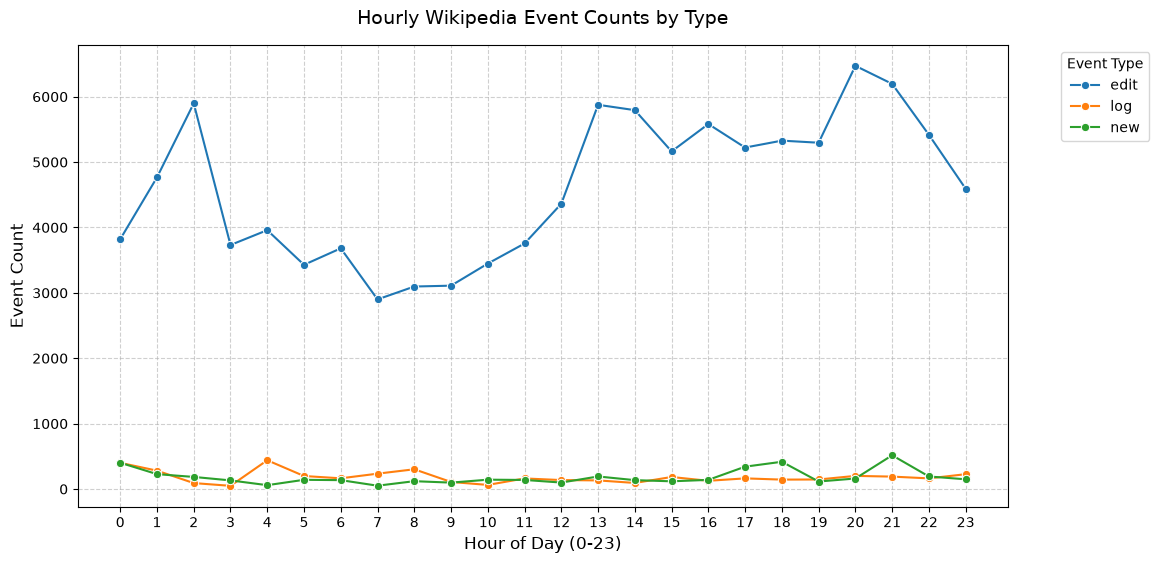

In [25]:
# Plot by hourly event type
plt.figure(figsize=(12, 6))

sns.lineplot(data=df_typed_hourly, x='hour', y='event_count', hue='type', marker='o')

plt.title("Hourly Wikipedia Event Counts by Type", fontsize=14, pad=15)
plt.xlabel("Hour of Day (0-23)", fontsize=12)
plt.ylabel("Event Count", fontsize=12)
plt.xticks(range(0, 24))
plt.legend(title="Event Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

# Save files
plt.savefig("images/events-by-type.svg", format="svg", bbox_inches="tight")
plt.savefig("images/events-by-type.png", format="png", dpi=300, bbox_inches="tight")

plt.show()